# Module 2.5 — SIMPLE Algorithm

**The algorithm that powers ANSYS Fluent, OpenFOAM (simpleFoam), and most industrial CFD codes.**
SIMPLE (Semi-Implicit Method for Pressure-Linked Equations, Patankar & Spalding 1972) is the standard method for solving the incompressible N-S equations. Over 50 years after its invention, it remains the dominant approach in commercial CFD.

**The core idea:**
Guess a pressure, solve momentum, check whether the result is divergence-free. If not — it won't be — use the divergence error to compute a pressure correction that fixes it. Repeat until converged.

**Roadmap:**
1. The predictor-corrector philosophy — why SIMPLE works
2. Step-by-step derivation — every equation derived from first principles
3. Under-relaxation — why it is necessary and how to choose the factors
4. Convergence monitoring — what residuals to track
5. SIMPLE variants: SIMPLEC, SIMPLER, PISO
6. Implementation on a lid-driven cavity

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. The Predictor-Corrector Philosophy

### Why not solve momentum and PPE simultaneously?

The fully coupled system — momentum + continuity — is a large, sparse, nonlinear system. Solving it directly requires storing the full Jacobian and doing Newton iterations. For a $100 \times 100$ grid in 2D with 3 unknowns per cell (u, v, p), that is a $30,000 \times 30,000$ matrix. Impractical.

SIMPLE splits the problem into two smaller ones:
1. **Momentum** — a linear system for $\mathbf{u}^*$ given $p^*$ (one linear solve per component)
2. **Pressure correction** — a Poisson equation for $p'$ given $\mathbf{u}^*$ (one Poisson solve)

Each sub-problem is much cheaper. The cost is iteration — you need to repeat this loop 50–500 times before the solution converges.

### The SIMPLE loop in plain English

```
INITIALISE: u=0, v=0, p=0 (or previous time step)

REPEAT (outer SIMPLE iterations):
  1. PREDICT u* from momentum using current p*:
       u* = f(u_old, v_old, p*)  ← not divergence-free
       v* = g(u_old, v_old, p*)

  2. COMPUTE divergence error:
       b = (u*_E - u*_W)/Δx + (v*_N - v*_S)/Δy  ← should be 0, isn't

  3. SOLVE pressure correction:
       ∇²p' = ρ/Δt * b  ← Poisson equation for p'

  4. CORRECT velocity and pressure:
       u = u* - (Δt/ρ) * ∂p'/∂x
       v = v* - (Δt/ρ) * ∂p'/∂y
       p = p* + αp * p'   ← under-relaxation

  5. CHECK residuals: if converged → STOP
     else → set p* = p, go to step 1

ADVANCE to next time step (or done for steady flow)
```

## 2. Step-by-Step Derivation

### Step 1: Momentum predictor

Discretise the momentum equation using the **current** pressure $p^*$:

$$\frac{\mathbf{u}^* - \mathbf{u}^n}{\Delta t} = -\frac{\nabla p^*}{\rho} - (\mathbf{u}^n\cdot\nabla)\mathbf{u}^n + \nu\nabla^2\mathbf{u}^n$$

This gives $\mathbf{u}^*$ — a velocity field that satisfies momentum but **not continuity**.

### Step 2: Correct the velocity to satisfy continuity

Decompose the final solution as $\mathbf{u} = \mathbf{u}^* + \mathbf{u}'$ and $p = p^* + p'$. Substituting into momentum (simplified — neglecting the correction to convective terms):

$$\frac{\mathbf{u}'}{\Delta t} = -\frac{\nabla p'}{\rho}$$

$$\implies \mathbf{u}' = -\frac{\Delta t}{\rho}\nabla p'$$

### Step 3: Enforce continuity on the corrected velocity

$$\nabla\cdot\mathbf{u} = \nabla\cdot\mathbf{u}^* + \nabla\cdot\mathbf{u}' = 0$$

$$\nabla\cdot\mathbf{u}^* - \frac{\Delta t}{\rho}\nabla^2 p' = 0$$

$$\boxed{\nabla^2 p' = \frac{\rho}{\Delta t}\nabla\cdot\mathbf{u}^*}$$

This is the **pressure correction Poisson equation**. Solve it for $p'$, then correct.

## 3. Under-Relaxation — Why It Is Necessary

### The problem without under-relaxation

SIMPLE is derived using an approximation: the correction to the convective terms is neglected. This approximation introduces an over-correction tendency — each iteration may overshoot, leading to oscillation or divergence.

### The fix: damped updates

$$\phi^{\text{new}} = \phi^{\text{old}} + \alpha(\phi^{\text{computed}} - \phi^{\text{old}})$$

where $\alpha \in (0,1]$ is the under-relaxation factor. $\alpha = 1$ means full update (no damping). $\alpha = 0.3$ means only 30% of the computed change is applied each iteration.

**Typical values:**
- Velocity: $\alpha_u = 0.7$ (moderate damping)
- Pressure: $\alpha_p = 0.3$ (strong damping)
- Turbulence quantities: $\alpha_k = 0.5$–$0.8$

**The Patankar guideline:** $\alpha_u + \alpha_p \approx 1.0$. Too large → diverge. Too small → converge very slowly. Trial and error in practice.

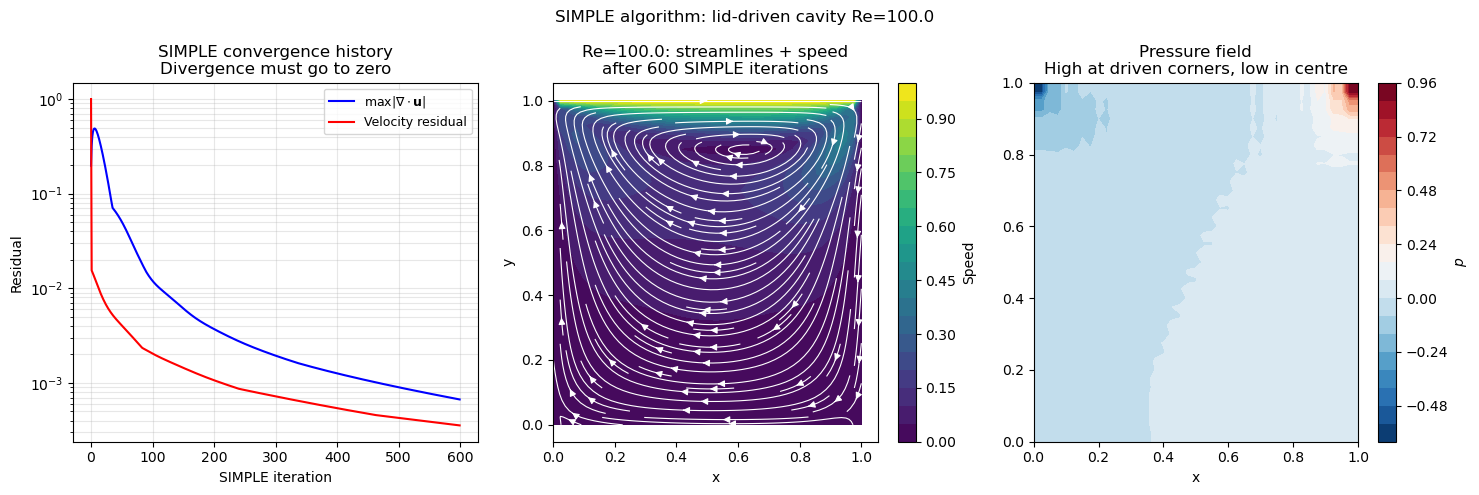

Final divergence:   6.69e-04  ← should be small
Velocity residual:  3.56e-04  ← approaches zero at convergence


In [2]:
# ── SIMPLE on a lid-driven cavity: Re = 100 ──────────────────────────────────
# Grid: N×N cell-centred, co-located (simplified — real SIMPLE uses staggered)
# This is a pedagogical implementation that shows the SIMPLE loop clearly.

def solve_poisson_jacobi(p, rhs, dx, dy, nit=50):
    """Fixed-iteration Jacobi Poisson solver."""
    for _ in range(nit):
        p[1:-1, 1:-1] = (
            (p[1:-1, 2:] + p[1:-1, :-2]) / dx**2 +
            (p[2:, 1:-1] + p[:-2, 1:-1]) / dy**2 -
            rhs[1:-1, 1:-1]
        ) / (2/dx**2 + 2/dy**2)
        p[0,:]=p[1,:]; p[-1,:]=p[-2,:]
        p[:,0]=p[:,1]; p[:,-1]=p[:,-2]
    p -= p.mean()
    return p

# ── Parameters ───────────────────────────────────────────────────────────────
N     = 41
L     = 1.0
dx = dy = L / (N-1)
Re    = 100.0
nu    = 1.0 / Re
rho   = 1.0
dt    = 0.001
alpha_p = 0.1   # pressure under-relaxation (strong to stabilise the simple loop)

# ── Fields ───────────────────────────────────────────────────────────────────
u = np.zeros((N, N))
v = np.zeros((N, N))
p = np.zeros((N, N))
u[-1, :] = 1.0   # lid BC: top wall moves at u=1

# ── SIMPLE iterations ─────────────────────────────────────────────────────────
n_iter    = 600
div_hist  = []    # max divergence — should decrease
res_u_hist = []   # velocity residual

for it in range(n_iter):
    u_old = u.copy();  v_old = v.copy()

    # ── Step 1: Momentum predictor ────────────────────────────────────────────
    u_star = u_old.copy();  v_star = v_old.copy()

    # x-momentum: upwind convection + central diffusion + pressure gradient
    u_star[1:-1, 1:-1] = (
        u_old[1:-1, 1:-1]
        # Upwind convection
        - dt * u_old[1:-1,1:-1] * (u_old[1:-1,1:-1] - u_old[1:-1,:-2]) / dx
        - dt * v_old[1:-1,1:-1] * (u_old[1:-1,1:-1] - u_old[:-2,1:-1]) / dy
        # Pressure gradient (central)
        - dt/rho * (p[1:-1,2:] - p[1:-1,:-2]) / (2*dx)
        # Viscous diffusion (central)
        + dt * nu * ((u_old[1:-1,2:] - 2*u_old[1:-1,1:-1] + u_old[1:-1,:-2])/dx**2
                   + (u_old[2:,1:-1] - 2*u_old[1:-1,1:-1] + u_old[:-2,1:-1])/dy**2)
    )

    # y-momentum
    v_star[1:-1, 1:-1] = (
        v_old[1:-1, 1:-1]
        - dt * u_old[1:-1,1:-1] * (v_old[1:-1,1:-1] - v_old[1:-1,:-2]) / dx
        - dt * v_old[1:-1,1:-1] * (v_old[1:-1,1:-1] - v_old[:-2,1:-1]) / dy
        - dt/rho * (p[2:,1:-1] - p[:-2,1:-1]) / (2*dy)
        + dt * nu * ((v_old[1:-1,2:] - 2*v_old[1:-1,1:-1] + v_old[1:-1,:-2])/dx**2
                   + (v_old[2:,1:-1] - 2*v_old[1:-1,1:-1] + v_old[:-2,1:-1])/dy**2)
    )

    # BCs on u*, v*
    u_star[0,:]=0; u_star[-1,:]=1.0; u_star[:,0]=0; u_star[:,-1]=0
    v_star[0,:]=0; v_star[-1,:]=0;   v_star[:,0]=0; v_star[:,-1]=0

    # ── Step 2: Build PPE RHS (divergence of u*) ──────────────────────────────
    # div(u*) = du*/dx + dv*/dy — central differences
    div = ((u_star[1:-1,2:] - u_star[1:-1,:-2])/(2*dx)
         + (v_star[2:,1:-1] - v_star[:-2,1:-1])/(2*dy))
    rhs_pp = np.zeros_like(p)
    rhs_pp[1:-1, 1:-1] = rho/dt * div

    # ── Step 3: Solve pressure correction ────────────────────────────────────
    p_prime = solve_poisson_jacobi(np.zeros_like(p), rhs_pp, dx, dy)

    # ── Step 4: Correct velocity and pressure ─────────────────────────────────
    u[1:-1,1:-1] = u_star[1:-1,1:-1] - dt/rho * (p_prime[1:-1,2:]-p_prime[1:-1,:-2])/(2*dx)
    v[1:-1,1:-1] = v_star[1:-1,1:-1] - dt/rho * (p_prime[2:,1:-1]-p_prime[:-2,1:-1])/(2*dy)
    p += alpha_p * p_prime

    # Re-apply BCs
    u[0,:]=0; u[-1,:]=1.0; u[:,0]=0; u[:,-1]=0
    v[0,:]=0; v[-1,:]=0;   v[:,0]=0; v[:,-1]=0

    # ── Monitor: divergence of corrected velocity ──────────────────────────────
    div_full = ((u[1:-1,2:]-u[1:-1,:-2])/(2*dx)
              + (v[2:,1:-1]-v[:-2,1:-1])/(2*dy))
    div_hist.append(np.max(np.abs(div_full)))
    res_u_hist.append(np.max(np.abs(u - u_old)))

# ── Plots ─────────────────────────────────────────────────────────────────────
x_arr = np.linspace(0, L, N)
y_arr = np.linspace(0, L, N)
Xg, Yg = np.meshgrid(x_arr, y_arr)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Convergence
axes[0].semilogy(div_hist, 'b-', lw=1.5, label='$\\max|\\nabla\\cdot\\mathbf{u}|$')
axes[0].semilogy(res_u_hist, 'r-', lw=1.5, label='Velocity residual')
axes[0].set_xlabel('SIMPLE iteration'); axes[0].set_ylabel('Residual')
axes[0].set_title('SIMPLE convergence history\nDivergence must go to zero')
axes[0].legend(fontsize=9); axes[0].grid(True, which='both', alpha=0.3)

# Flow field
speed = np.sqrt(u**2 + v**2)
cf = axes[1].contourf(Xg, Yg, speed, levels=20, cmap='viridis')
plt.colorbar(cf, ax=axes[1], label='Speed')
axes[1].streamplot(Xg, Yg, u, v, color='white', density=1.5, linewidth=0.8)
axes[1].set_title(f'Re={Re}: streamlines + speed\nafter {n_iter} SIMPLE iterations')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')

# Pressure field
cf2 = axes[2].contourf(Xg, Yg, p, levels=20, cmap='RdBu_r')
plt.colorbar(cf2, ax=axes[2], label='$p$')
axes[2].set_title('Pressure field\nHigh at driven corners, low in centre')
axes[2].set_xlabel('x')

plt.suptitle(f'SIMPLE algorithm: lid-driven cavity Re={Re}', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Final divergence:   {div_hist[-1]:.2e}  ← should be small')
print(f'Velocity residual:  {res_u_hist[-1]:.2e}  ← approaches zero at convergence')

## 4. SIMPLE Variants — When to Use Each

| Variant | Key modification | Advantage | When to use |
|---------|-----------------|-----------|-------------|
| **SIMPLE** | Neglects correction to convective terms | Simple to implement | Steady-state, learning |
| **SIMPLEC** | Corrects the neighbour coefficient sum | Less under-relaxation needed, faster | Steady-state, most cases |
| **SIMPLER** | Solves full PPE for pressure (not just correction) | Better pressure solution | When pressure accuracy critical |
| **PISO** | Two correction steps per time step | Time-accurate; stable at larger dt | **Unsteady flows** (OpenFOAM icoFoam) |

**OpenFOAM defaults:**
- Steady-state: `simpleFoam` uses SIMPLE
- Unsteady laminar: `icoFoam` uses PISO
- Unsteady turbulent: `pimpleFoam` uses PIMPLE (SIMPLE + PISO hybrid)

## Summary

| Step | What it does | Key equation |
|------|-------------|-------------|
| 1. Momentum predictor | Advance $\mathbf{u}$ using current $p^*$ | $\mathbf{u}^* = \mathbf{u}^n + \Delta t \cdot (-\nabla p^*/\rho + \ldots)$ |
| 2. Divergence error | Check how far $\mathbf{u}^*$ is from div-free | $b = \nabla\cdot\mathbf{u}^*$ |
| 3. Pressure correction | Solve PPE for $p'$ that fixes continuity | $\nabla^2 p' = (\rho/\Delta t)b$ |
| 4. Velocity correction | Make $\mathbf{u}$ divergence-free | $\mathbf{u} = \mathbf{u}^* - (\Delta t/\rho)\nabla p'$ |
| 5. Pressure update | Damp new pressure | $p = p^* + \alpha_p p'$ |

---
**Next:** Module 2.6 — Lid-Driven Cavity: the canonical CFD benchmark, full implementation, and validation against Ghia et al. (1982).